(10500, 7)
method
conrad               1500
first_order_gram      500
fourth_order_gram    1500
gaussian             1500
ics                  1500
real                  500
second_order_gram     500
third_order_gram     1500
truncated_normal     1500
Name: step, dtype: int64


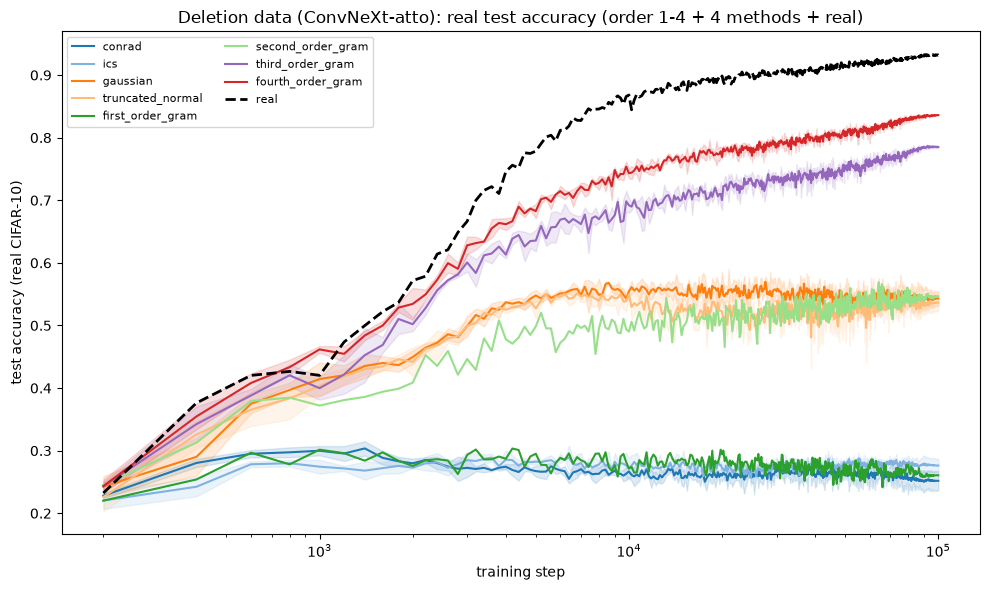

In [1]:
# ══════════════════════════════════════════════════════════════
# Cell A: Learning curve data (8 conditions: 4 baseline methods + order 1-4 + real)
# ══════════════════════════════════════════════════════════════
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

LLC_RESULTS_DIR = Path("/home/nakano/server/llc_results_dense")

records = []

for fname in [
    LLC_RESULTS_DIR / "deletion_vision_full_curve_gpu2.jsonl",
    LLC_RESULTS_DIR / "deletion_vision_full_curve_gpu3.jsonl",
]:
    with open(fname) as f:
        for line in f:
            records.append(json.loads(line))

GRAM_METHODS_SEEDS = {
    "first_order_gram":  ["seed42"],
    "second_order_gram": ["seed42"],
    "third_order_gram":  ["seed42", "seed43", "seed44"],
    "fourth_order_gram": ["seed42", "seed43", "seed44"],
}
for method, seeds in GRAM_METHODS_SEEDS.items():
    for seed in seeds:
        fname = LLC_RESULTS_DIR / f"deletion_vision_{method}_convnext_{seed}.jsonl"
        if not fname.exists():
            print(f"[skip] {fname} not found")
            continue
        with open(fname) as f:
            for line in f:
                records.append(json.loads(line))

df = pd.DataFrame(records)

real_csv = LLC_RESULTS_DIR / "deletion_vision_real_convnext_seed42.csv"
if real_csv.exists():
    real_df = pd.read_csv(real_csv)
    if "test_acc" in real_df.columns and "train_acc" not in real_df.columns:
        real_df["train_acc"] = real_df["test_acc"]
    if "test_loss" in real_df.columns and "train_loss" not in real_df.columns:
        real_df["train_loss"] = real_df["test_loss"]
    real_df["method"] = "real"
    keep_cols = ["method", "step", "train_acc", "train_loss", "test_acc", "test_loss"]
    real_df = real_df[[c for c in keep_cols if c in real_df.columns]]
    df = pd.concat([df, real_df], ignore_index=True)

print(df.shape)
print(df.groupby("method")["step"].count())

METHODS = ["conrad", "ics", "gaussian", "truncated_normal",
           "first_order_gram", "second_order_gram",
           "third_order_gram", "fourth_order_gram", "real"]
metrics = ["train_acc", "train_loss", "test_acc", "test_loss"]

summary = df.groupby(["method", "step"])[metrics].agg(["mean", "std"])
summary.columns = ["_".join(c) for c in summary.columns]
summary = summary.reset_index()

COLOR_MAP = {
    "conrad": "#1f77b4", "ics": "#7fb2e0",
    "gaussian": "#ff7f0e", "truncated_normal": "#ffbb78",
    "first_order_gram": "#2ca02c", "second_order_gram": "#98df8a",
    "third_order_gram": "#9467bd", "fourth_order_gram": "#d62728",
    "real": "black",
}

def plot_metric(metric_name, ylabel, title, save_name):
    fig, ax = plt.subplots(figsize=(10, 6))
    for method in METHODS:
        sub = summary[summary["method"] == method].sort_values("step")
        if sub.empty:
            continue
        style = "--" if method == "real" else "-"
        ax.plot(sub["step"], sub[f"{metric_name}_mean"], style,
                 label=method, color=COLOR_MAP[method],
                 linewidth=2 if method == "real" else 1.5)
        ax.fill_between(
            sub["step"],
            sub[f"{metric_name}_mean"] - sub[f"{metric_name}_std"],
            sub[f"{metric_name}_mean"] + sub[f"{metric_name}_std"],
            color=COLOR_MAP[method], alpha=0.15,
        )
    ax.set_xlabel("training step")
    ax.set_xscale("log")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.savefig(f"/home/nakano/server/llc_results_dense/{save_name}.png", dpi=150)
    plt.show()

plot_metric("test_acc", "test accuracy (real CIFAR-10)",
            "Deletion data (ConvNeXt-atto): real test accuracy (order 1-4 + 4 methods + real)",
            "deletion_vision_test_acc_all")

Loaded records: ['conrad', 'ics', 'gaussian', 'truncated_normal', 'first_order_gram', 'second_order_gram', 'third_order_gram', 'fourth_order_gram', 'real']
conrad               ['8.85', '10.67', '11.90', '12.22']
ics                  ['-7.54', '-7.08', '-6.56', '-6.38']
gaussian             ['109.07', '146.71', '173.29', '181.91']
truncated_normal     ['129.97', '164.49', '186.92', '193.92']
first_order_gram     ['-0.88', '-0.20', '0.13', '0.32']
second_order_gram    ['28.13', '34.58', '37.88', '38.98']
third_order_gram     ['58.10', '73.48', '84.00', '88.19']
fourth_order_gram    ['79.20', '100.73', '115.48', '121.28']
real                 ['165.25', '213.76', '250.91', '264.26']


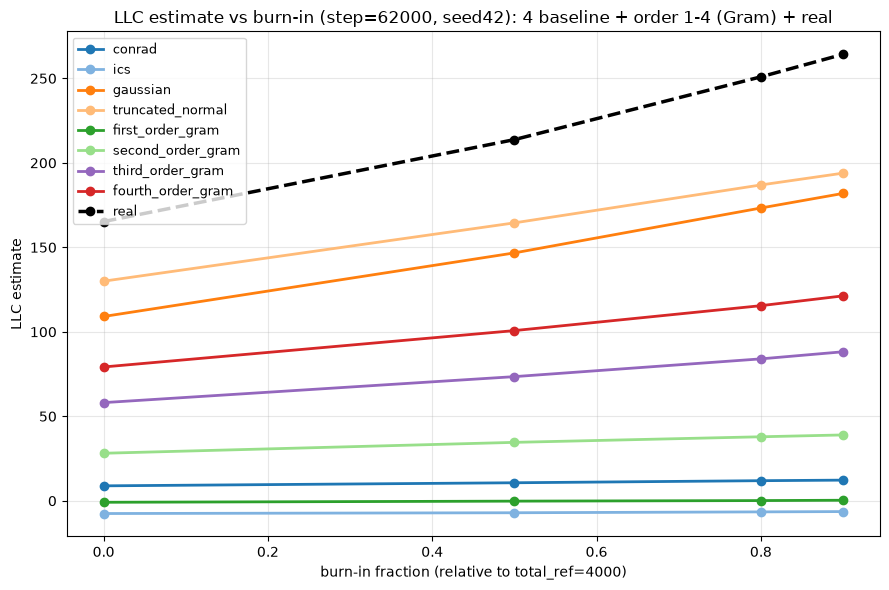

In [2]:
# ══════════════════════════════════════════════════════════════
# LLC comparison (seed42, step=62000): 4 baseline + order 1-4 (Gram) + real
# ══════════════════════════════════════════════════════════════
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DELETION_ROOT = Path("/home/nakano/server/calibration_results_deletion_vision_resnet_setting")

def load_matching(fpath, step_filter=None):
    if not fpath.exists():
        return None
    d = json.load(open(fpath))
    recs = [r for r in d["records"]
            if abs(r["epsilon"] - 2e-7) < 1e-9 and r["total_steps"] == 8000
            and (step_filter is None or r["step"] == step_filter)]
    return recs[0] if recs else None

all_records = {}

for method in ["conrad", "ics", "gaussian", "truncated_normal"]:
    r = load_matching(DELETION_ROOT / f"calib_convnext-atto_deletion_{method}_step62000.json")
    if r:
        all_records[method] = r

for method in ["first_order_gram", "second_order_gram", "third_order_gram", "fourth_order_gram"]:
    fpath = DELETION_ROOT / f"calib_convnext-atto_deletion_{method}_seed42_step62000.json"
    r = load_matching(fpath, step_filter=62000)
    if r:
        all_records[method] = r

r = load_matching(DELETION_ROOT / "calib_convnext-atto_step62000.json", step_filter=62000)
if r:
    all_records["real"] = r

print("Loaded records:", list(all_records.keys()))

COLOR_MAP = {
    "conrad": "#1f77b4", "ics": "#7fb2e0",
    "gaussian": "#ff7f0e", "truncated_normal": "#ffbb78",
    "first_order_gram": "#2ca02c", "second_order_gram": "#98df8a",
    "third_order_gram": "#9467bd", "fourth_order_gram": "#d62728",
    "real": "black",
}

def compute_llc_from_trace(loss_trace, l_w_star, nbeta, burn_in_frac=0.0, total_ref=None):
    loss_trace = np.array(loss_trace)
    base = total_ref if total_ref is not None else len(loss_trace)
    n_burn = min(int(base * burn_in_frac), len(loss_trace) - 1)
    tail = loss_trace[n_burn:]
    return nbeta * (np.mean(tail) - l_w_star)

burn_in_fracs = [0.0, 0.5, 0.8, 0.9]
total_ref = 4000

llc_by_burnin = {name: [] for name in all_records}
for name, r in all_records.items():
    l_w_star_approx = np.mean(r["loss_trace"][:5])
    nbeta = r["nbeta"]
    for frac in burn_in_fracs:
        llc = compute_llc_from_trace(r["loss_trace"], l_w_star_approx, nbeta,
                                       burn_in_frac=frac, total_ref=total_ref)
        llc_by_burnin[name].append(llc)

for name in all_records:
    print(f"{name:20s}", [f"{v:.2f}" for v in llc_by_burnin[name]])

fig, ax = plt.subplots(figsize=(9, 6))
for name in all_records:
    style = "--" if name == "real" else "-"
    lw = 2.5 if name == "real" else 2
    ax.plot(burn_in_fracs, llc_by_burnin[name], style, marker="o", linewidth=lw,
             label=name, color=COLOR_MAP.get(name, "gray"))
ax.set_xlabel(f"burn-in fraction (relative to total_ref={total_ref})")
ax.set_ylabel("LLC estimate")
ax.set_title("LLC estimate vs burn-in (step=62000, seed42): 4 baseline + order 1-4 (Gram) + real")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/home/nakano/server/llc_results_dense/llc_vs_burnin_with_real.png", dpi=150)
plt.show()

Loaded records: ['conrad', 'ics', 'gaussian', 'truncated_normal', 'first_order_gram', 'second_order_gram', 'third_order_gram', 'fourth_order_gram', 'real']
conrad               ['8.85', '10.67', '11.90', '12.22']
ics                  ['-7.54', '-7.08', '-6.56', '-6.38']
gaussian             ['109.07', '146.71', '173.29', '181.91']
truncated_normal     ['129.97', '164.49', '186.92', '193.92']
first_order_gram     ['-0.88', '-0.20', '0.13', '0.32']
second_order_gram    ['28.13', '34.58', '37.88', '38.98']
third_order_gram     ['58.10', '73.48', '84.00', '88.19']
fourth_order_gram    ['79.20', '100.73', '115.48', '121.28']
real                 ['165.25', '213.76', '250.91', '264.26']


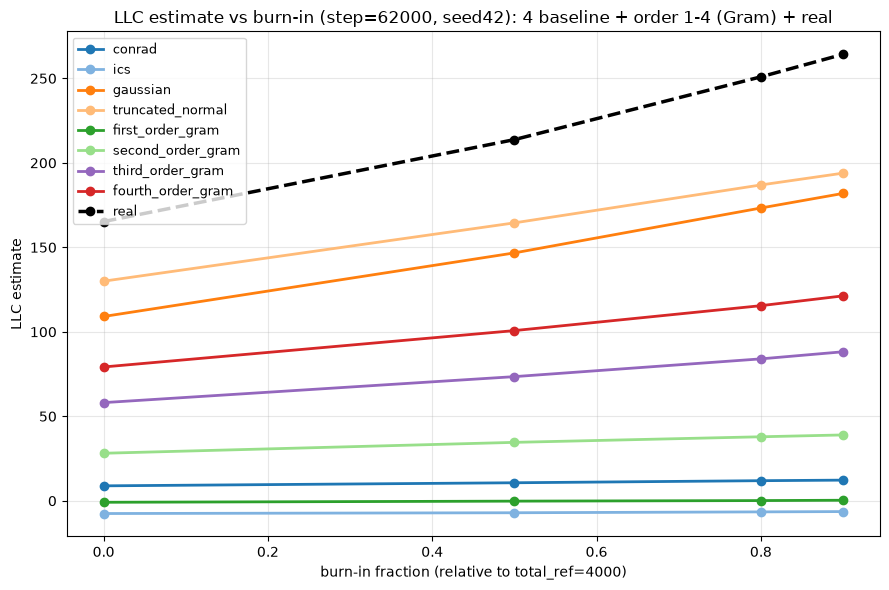

In [ ]:
# ══════════════════════════════════════════════════════════════
# LLC comparison (seed42, step=62000): 4 baseline + order 1-4 (Gram) + real
# ══════════════════════════════════════════════════════════════
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DELETION_ROOT = Path("/home/nakano/server/calibration_results_deletion_vision_resnet_setting")

def load_matching(fpath, step_filter=None):
    if not fpath.exists():
        return None
    d = json.load(open(fpath))
    recs = [r for r in d["records"]
            if abs(r["epsilon"] - 2e-7) < 1e-9 and r["total_steps"] == 8000
            and (step_filter is None or r["step"] == step_filter)]
    return recs[0] if recs else None

all_records: dict[str, dict] = {}

'''
for method in ["conrad", "ics", "gaussian", "truncated_normal"]:
    r = load_matching(DELETION_ROOT / f"calib_convnext-atto_deletion_{method}_step62000.json")
    if r:
        all_records[method] = r
'''
for method in ["first_order_gram", "second_order_gram", "third_order_gram", "fourth_order_gram"]:
    fpath = DELETION_ROOT / f"calib_convnext-atto_deletion_{method}_seed42_step62000.json"
    r = load_matching(fpath, step_filter=62000)
    if r:
        all_records[method] = r

r = load_matching(DELETION_ROOT / "calib_convnext-atto_step62000.json", step_filter=62000)
if r:
    all_records["real"] = r

print("Loaded records:", list(all_records.keys()))

COLOR_MAP = {
    "conrad": "#1f77b4", "ics": "#7fb2e0",
    "gaussian": "#ff7f0e", "truncated_normal": "#ffbb78",
    "first_order_gram": "#2ca02c", "second_order_gram": "#98df8a",
    "third_order_gram": "#9467bd", "fourth_order_gram": "#d62728",
    "real": "black",
}

def compute_llc_from_trace(loss_trace, l_w_star, nbeta, burn_in_frac=0.0, total_ref=None):
    loss_trace = np.array(loss_trace)
    base = total_ref if total_ref is not None else len(loss_trace)
    n_burn = min(int(base * burn_in_frac), len(loss_trace) - 1)
    tail = loss_trace[n_burn:]
    return nbeta * (np.mean(tail) - l_w_star)

burn_in_fracs = [0.0, 0.5, 0.8, 0.9]
total_ref = 4000

llc_by_burnin = {name: [] for name in all_records}
for name, r in all_records.items():
    l_w_star_approx = np.mean(r["loss_trace"][:5])
    nbeta = r["nbeta"]
    for frac in burn_in_fracs:
        llc = compute_llc_from_trace(r["loss_trace"], l_w_star_approx, nbeta,
                                       burn_in_frac=frac, total_ref=total_ref)
        llc_by_burnin[name].append(llc)

for name in all_records:
    print(f"{name:20s}", [f"{v:.2f}" for v in llc_by_burnin[name]])

fig, ax = plt.subplots(figsize=(9, 6))
for name in all_records:
    style = "--" if name == "real" else "-"
    lw = 2.5 if name == "real" else 2
    ax.plot(burn_in_fracs, llc_by_burnin[name], style, marker="o", linewidth=lw,
             label=name, color=COLOR_MAP.get(name, "gray"))
ax.set_xlabel(f"burn-in fraction (relative to total_ref={total_ref})")
ax.set_ylabel("LLC estimate")
ax.set_title("LLC estimate vs burn-in (step=62000, seed42): 4 baseline + order 1-4 (Gram) + real")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/home/nakano/server/llc_results_dense/llc_vs_burnin_with_real.png", dpi=150)
plt.show()